# Predicting Six-Month Outcomes After Acute Ischemic Stroke

### Cross-Validated Models for Mortality, Dependency, and Recovery Using International Stroke Trial Data

## 1. Data Preparation

In [3]:
# Date for random seed
date = 20260717

from pathlib import Path
import pandas as pd

# Load data
data_path = Path(
    "/Users/subspace/Desktop/JHU Courses/"
    "Theory of Machine Learning/Final Project/"
    "Stroke/1745-6215-12-101-S1.CSV"
)

ist = pd.read_csv(data_path, low_memory=False)

# Standardize column names
ist.columns = ist.columns.str.strip().str.upper()

# Define candidate predictors
numeric_predictors = [
    # Demographics and timing
    "AGE", "RDELAY",
    
    # Baseline clinical status
    "RSBP",
]

categorical_predictors = [
    # Demographics
    "SEX",
    
    # Baseline clinical status
    "RCONSC", "RATRIAL", "RSLEEP", "STYPE",

    # Baseline neurological deficits
    "RDEF1", "RDEF2", "RDEF3", "RDEF4",
    "RDEF5", "RDEF6", "RDEF7", "RDEF8",

    # Pretreatment and imaging information
    "RASP3", "RHEP24", "RCT", "RVISINF",

    # Randomized treatment assignments
    "RXASP", "RXHEP",
]

predictors = numeric_predictors + categorical_predictors
outcomes = ["FDEAD", "FDENNIS", "FRECOVER"]

# RVISINF is retained as a predictive feature. However, CT timing varied, so
# infarct visibility was not available for every patient at randomization.
# The resulting model should therefore be interpreted as predicting six-month
# outcomes using early clinical information, not strictly information available
# at the exact moment of randomization. The broader candidate predictor set is
# retained for subsequent feature selection.

ist = ist[predictors + outcomes].copy()

# Standardize categorical predictor and outcome values
text_columns = categorical_predictors + outcomes
ist[text_columns] = ist[text_columns].apply(
    lambda column: column.astype("string").str.strip().str.upper()
)

# Unknown outcome values are not usable targets
ist[outcomes] = ist[outcomes].replace("U", pd.NA)

# H was the pilot-phase code for the medium-dose heparin arm
ist["RXHEP"] = ist["RXHEP"].replace("H", "M")

# Retain predictors with limited missingness and encode missing categorical
# values as a separate level. This preserves observations and allows the model
# to capture potentially informative missingness, including variables that were
# not recorded during the pilot phase.

ist[categorical_predictors] = (
    ist[categorical_predictors]
    .fillna("Missing")
)
ist.head()

,AGE,RDELAY,RSBP,SEX,RCONSC,RATRIAL,RSLEEP,STYPE,RDEF1,RDEF2,...,RDEF8,RASP3,RHEP24,RCT,RVISINF,RXASP,RXHEP,FDEAD,FDENNIS,FRECOVER
0,69,17,140,M,D,Missing,Y,PACS,N,N,...,Y,Missing,Missing,Y,Y,Y,N,N,Y,N
1,76,10,150,M,F,Missing,Y,LACS,Y,Y,...,N,Missing,Missing,Y,N,N,L,N,Y,N
2,71,43,170,F,F,Missing,N,LACS,Y,Y,...,N,Missing,Missing,Y,N,Y,N,N,Y,N
3,81,6,170,M,F,Missing,N,PACS,N,N,...,N,Missing,Missing,N,N,N,M,N,N,Y
4,78,20,170,M,F,Missing,N,LACS,Y,Y,...,N,Missing,Missing,N,N,Y,M,N,Y,N


In [4]:
# Summarize remaining missing values after cleaning
missing = (
    ist.isna()
    .sum()
    .to_frame("n_missing")
)

missing["percent_missing"] = (
    100 * missing["n_missing"] / len(ist)
)

missing = missing.sort_values(
    "percent_missing",
    ascending=False
)

missing.head()

,n_missing,percent_missing
FRECOVER,4630,23.823000
FDENNIS,4553,23.426807
FDEAD,156,0.802676
RDEF6,0,0.000000
RXHEP,0,0.000000


In [5]:
# Look at the data
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
ist.head()

,AGE,RDELAY,RSBP,SEX,RCONSC,RATRIAL,RSLEEP,STYPE,RDEF1,RDEF2,RDEF3,RDEF4,RDEF5,RDEF6,RDEF7,RDEF8,RASP3,RHEP24,RCT,RVISINF,RXASP,RXHEP,FDEAD,FDENNIS,FRECOVER
0,69,17,140,M,D,Missing,Y,PACS,N,N,N,Y,N,Y,N,Y,Missing,Missing,Y,Y,Y,N,N,Y,N
1,76,10,150,M,F,Missing,Y,LACS,Y,Y,Y,N,N,N,N,N,Missing,Missing,Y,N,N,L,N,Y,N
2,71,43,170,F,F,Missing,N,LACS,Y,Y,Y,N,N,N,N,N,Missing,Missing,Y,N,Y,N,N,Y,N
3,81,6,170,M,F,Missing,N,PACS,N,N,N,Y,N,N,N,N,Missing,Missing,N,N,N,M,N,N,Y
4,78,20,170,M,F,Missing,N,LACS,Y,Y,Y,N,N,N,N,N,Missing,Missing,N,N,Y,M,N,Y,N


## 2. Outcome Definitions and Class Distributions

In [7]:
from IPython.display import Markdown, display

# Create an outcome-specific dataset by retaining the candidate predictors and
# the selected outcome. Remove only observations for which that outcome is
# missing because each outcome will be modeled separately.
def get_outcome_data(data, outcome):
    return (
        data[predictors + [outcome]]
        .dropna(subset=[outcome])
        .copy()
    )


# Create a separate modeling dataset for each six-month outcome. Each dataset
# retains the common predictor set and excludes only observations for which its
# selected outcome is missing:
#
# - fdead_data includes patients with a recorded six-month mortality status.
# - fdennis_data includes patients with a recorded six-month dependency status.
# - frecover_data includes patients with a recorded six-month recovery status.
#
# The datasets may therefore contain different patients and sample sizes.
# If dependency and recovery were not assessed for patients who died, those
# patients will be excluded from the FDENNIS and FRECOVER models. In that case,
# these models should be interpreted as predicting dependency or recovery among
# patients with an observed functional outcome, rather than among the complete
# randomized cohort.

fdead_data = get_outcome_data(ist, "FDEAD")
fdennis_data = get_outcome_data(ist, "FDENNIS")
frecover_data = get_outcome_data(ist, "FRECOVER")


# Summarize the usable sample size and class distribution for each outcome.
# Display the results as separate formatted tables for easier comparison.
for outcome, data in {
    "FDEAD": fdead_data,
    "FDENNIS": fdennis_data,
    "FRECOVER": frecover_data,
}.items():

    # Calculate the number and percentage of observations in each class.
    counts = data[outcome].value_counts()
    percentages = (
        data[outcome]
        .value_counts(normalize=True)
        .mul(100)
    )

    summary = pd.DataFrame({
        "count": counts,
        "percent": percentages,
    })

    # Label the index and format the displayed values.
    summary.index.name = "class"
    summary["count"] = summary["count"].map(
        lambda value: f"{value:,}"
    )
    summary["percent"] = summary["percent"].map(
        lambda value: f"{value:.2f}%"
    )

    # Display the outcome name and usable sample size above each table.
    display(
        Markdown(
            f"##### {outcome}: {len(data):,} usable observations"
        )
    )
    display(summary)

##### FDEAD: 19,279 usable observations

,count,percent
class,,
N,"14,910",77.34%
Y,"4,369",22.66%


##### FDENNIS: 14,882 usable observations

,count,percent
class,,
Y,"7,727",51.92%
N,"7,155",48.08%


##### FRECOVER: 14,805 usable observations

,count,percent
class,,
N,"11,088",74.89%
Y,"3,717",25.11%


FDEAD and FRECOVER contain fewer positive than negative outcomes, whereas FDENNIS is approximately balanced. The outcome-specific training and held-out test sets preserved these distributions through stratified splitting. Balanced accuracy was therefore used as the primary model-selection metric for all three outcomes, with ROC-AUC, precision, recall, F1 score, and ordinary accuracy used to characterize discrimination and classification tradeoffs.

## 3. Shared Modeling Framework

### 3.1 Preprocessing

In [11]:
# Define a shared preprocessing framework for all outcome models. Numeric
# predictors are standardized so scale-sensitive classifiers can compare them
# appropriately, while categorical predictors are one-hot encoded using
# explicitly chosen reference levels for clear coefficient interpretation.
# The same preprocessing rules will later be fitted within each model pipeline
# ensuring consistent transformations across outcomes
# and preventing test-set information from entering model development.

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define categorical levels and clinically meaningful reference categories
category_specs = {
    # Demographics
    "SEX": {
        "categories": ["F", "M"],
        "reference": "F",
    },

    # Baseline clinical status
    "RCONSC": {
        "categories": ["F", "D", "U"],
        "reference": "F",
    },
    "RATRIAL": {
        "categories": ["N", "Y", "Missing"],
        "reference": "N",
    },
    "RSLEEP": {
        "categories": ["N", "Y"],
        "reference": "N",
    },
    "STYPE": {
        "categories": ["LACS", "PACS", "POCS", "TACS", "OTH"],
        "reference": "LACS",
    },

    # Baseline neurological deficits
    "RDEF1": {
        "categories": ["N", "Y", "C"],
        "reference": "N",
    },
    "RDEF2": {
        "categories": ["N", "Y", "C"],
        "reference": "N",
    },
    "RDEF3": {
        "categories": ["N", "Y", "C"],
        "reference": "N",
    },
    "RDEF4": {
        "categories": ["N", "Y", "C"],
        "reference": "N",
    },
    "RDEF5": {
        "categories": ["N", "Y", "C"],
        "reference": "N",
    },
    "RDEF6": {
        "categories": ["N", "Y", "C"],
        "reference": "N",
    },
    "RDEF7": {
        "categories": ["N", "Y", "C"],
        "reference": "N",
    },
    "RDEF8": {
        "categories": ["N", "Y", "C"],
        "reference": "N",
    },

    # Pretreatment and imaging information
    "RASP3": {
        "categories": ["N", "Y", "Missing"],
        "reference": "N",
    },
    "RHEP24": {
        "categories": ["N", "Y", "Missing"],
        "reference": "N",
    },
    "RCT": {
        "categories": ["N", "Y"],
        "reference": "N",
    },
    "RVISINF": {
        "categories": ["N", "Y"],
        "reference": "N",
    },

    # Randomized treatment assignments
    "RXASP": {
        "categories": ["N", "Y"],
        "reference": "N",
    },
    "RXHEP": {
        "categories": ["N", "L", "M"],
        "reference": "N",
    },
}

# Build category and reference lists in the same order as categorical_predictors
category_levels = [
    category_specs[column]["categories"]
    for column in categorical_predictors
]

reference_levels = [
    category_specs[column]["reference"]
    for column in categorical_predictors
]


In [12]:
# Construct a new preprocessing object for each outcome analysis. Numeric
# predictors are standardized, while categorical predictors are one-hot
# encoded using the prespecified reference categories.

def build_preprocessor():

    return ColumnTransformer(
        transformers=[
            (
                "num",
                StandardScaler(),
                numeric_predictors,
            ),
            (
                "cat",
                OneHotEncoder(
                    categories=category_levels,
                    drop=reference_levels,
                    handle_unknown="error",
                    sparse_output=False,
                ),
                categorical_predictors,
            ),
        ]
    )


### 3.2 Candidate Models

In [14]:
# Construct fresh model pipelines for each outcome. Every classifier receives
# the same predictors and preprocessing, while the applicable class-balancing
# mechanism is specified separately for each algorithm.

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.neural_network import MLPClassifier


def build_models():

    preprocessor = build_preprocessor()

    logistic_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=2000,
                    random_state=date,
                ),
            ),
        ]
    )

    random_forest_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                RandomForestClassifier(
                    n_estimators=500,
                    min_samples_leaf=5,
                    class_weight="balanced",
                    n_jobs=-1,
                    random_state=date,
                ),
            ),
        ]
    )

    lda_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LinearDiscriminantAnalysis(
                    priors=[0.5, 0.5],
                ),
            ),
        ]
    )

    qda_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                QuadraticDiscriminantAnalysis(
                    priors=[0.5, 0.5],
                    reg_param=0.1,
                ),
            ),
        ]
    )

    gradient_boosting_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                GradientBoostingClassifier(
                    random_state=date,
                ),
            ),
        ]
    )

    mlp_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                MLPClassifier(
                    max_iter=2000,
                    early_stopping=True,
                    random_state=date,
                ),
            ),
        ]
    )

    return {
        "Logistic Regression": logistic_pipeline,
        "Random Forest": random_forest_pipeline,
        "LDA": lda_pipeline,
        "QDA": qda_pipeline,
        "Gradient Boosting": gradient_boosting_pipeline,
        "Neural Network": mlp_pipeline,
    }


### 3.3 Cross-Validation and Hyperparameter Grids

In [16]:
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibrationDisplay

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import ScalarFormatter
from IPython.display import Markdown, display


# Use the same reproducible stratified folds for every outcome and model.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=date,
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
    "precision": make_scorer(
        precision_score,
        zero_division=0,
    ),
    "recall": "recall",
    "f1": "f1",
}


In [17]:
# Small prespecified hyperparameter grids for each model class
param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.1, 1, 10],
    },

    "Random Forest": {
        "classifier__max_depth": [None, 10, 20],
        "classifier__min_samples_leaf": [5, 10],
    },

    "LDA": [
        {
            "classifier__solver": ["svd"],
        },
        {
            "classifier__solver": ["lsqr"],
            "classifier__shrinkage": [None, "auto"],
        },
    ],

    "QDA": {
        "classifier__reg_param": [0.1, 0.25, 0.5, 0.75],
    },

    "Gradient Boosting": {
        "classifier__n_estimators": [100, 200],
        "classifier__learning_rate": [0.05, 0.1],
        "classifier__max_depth": [2, 3],
    },

    "Neural Network": {
        "classifier__hidden_layer_sizes": [(50,), (100,)],
        "classifier__alpha": [0.0001, 0.001],
    },
}

### 3.4 Analysis Function

In [19]:
def run_outcome_analysis(
    data,
    outcome,
    positive_label,
    negative_label,
):

    # --------------------------------------------------------------
    # Model development
    # --------------------------------------------------------------

    display(Markdown("### Model Development"))

    # Separate the common predictors from the selected outcome.
    X = data[predictors]
    y = data[outcome].map({"N": 0, "Y": 1})

    # Create an outcome-specific stratified 80/20 split.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=date,
    )

    split_summary = pd.DataFrame(
        {
            "observations": [
                len(X_train),
                len(X_test),
            ],
            "predictors": [
                X_train.shape[1],
                X_test.shape[1],
            ],
        },
        index=[
            "Training",
            "Held-out test",
        ],
    )

    display(split_summary)

    # Confirm that stratification preserved the outcome distribution.
    class_balance = pd.DataFrame(
        {
            "Training (%)": (
                y_train
                .value_counts(normalize=True)
                .mul(100)
            ),
            "Held-out test (%)": (
                y_test
                .value_counts(normalize=True)
                .mul(100)
            ),
        }
    )

    class_balance = (
        class_balance
        .rename(
            index={
                0: negative_label,
                1: positive_label,
            }
        )
        .round(2)
    )

    display(class_balance)

    # Construct fresh, unfitted pipelines for this outcome.
    models = build_models()

    # Create observation weights for classifiers that accept sample_weight
    # rather than a class_weight constructor argument.
    balanced_sample_weight = compute_sample_weight(
        class_weight="balanced",
        y=y_train,
    )

    tuned_models = {}
    tuning_results = []

    for model_name, model in models.items():

        # Display progress because the complete search may take some time.
        print(f"{outcome}: tuning {model_name}")

        search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[model_name],

            # Evaluate each configuration with all specified metrics.
            scoring=scoring,

            # Use the same stratified folds for every model.
            cv=cv,

            # Select the configuration with the highest validation
            # balanced accuracy and refit it on the full training set.
            refit="balanced_accuracy",

            # Retain training scores for the overfitting assessment.
            return_train_score=True,

            # Process one parameter configuration at a time.
            n_jobs=1,
        )

        fit_parameters = {}

        if model_name in {
            "Gradient Boosting",
            "Neural Network",
        }:
            fit_parameters["classifier__sample_weight"] = (
                balanced_sample_weight
            )

        search.fit(
            X_train,
            y_train,
            **fit_parameters,
        )

        # GridSearchCV has already refitted this pipeline on the complete
        # training set using the selected hyperparameters.
        tuned_models[model_name] = search.best_estimator_

        best_index = search.best_index_

        result = {
            "model": model_name,
            "best_parameters": search.best_params_,
        }

        # Retrieve the training and validation results for the selected
        # hyperparameter configuration.
        for metric in scoring:

            result[f"cv_train_{metric}_mean"] = (
                search.cv_results_[
                    f"mean_train_{metric}"
                ][best_index]
            )

            result[f"cv_validation_{metric}_mean"] = (
                search.cv_results_[
                    f"mean_test_{metric}"
                ][best_index]
            )

            result[f"cv_validation_{metric}_std"] = (
                search.cv_results_[
                    f"std_test_{metric}"
                ][best_index]
            )

        tuning_results.append(result)

    tuning_results = pd.DataFrame(tuning_results)

    # --------------------------------------------------------------
    # Cross-validation results
    # --------------------------------------------------------------

    display(Markdown("### Cross-Validation Results"))

    selection_summary = (
        tuning_results[
            [
                "model",
                "cv_validation_balanced_accuracy_mean",
                "cv_validation_balanced_accuracy_std",
                "best_parameters",
            ]
        ]
        .rename(
            columns={
                "cv_validation_balanced_accuracy_mean":
                    "balanced_accuracy_mean",
                "cv_validation_balanced_accuracy_std":
                    "balanced_accuracy_std",
            }
        )
        .set_index("model")
        .round(3)
    )

    with pd.option_context("display.max_colwidth", None):
        display(selection_summary)

    metrics = [
        "accuracy",
        "balanced_accuracy",
        "roc_auc",
        "precision",
        "recall",
        "f1",
    ]

    cv_performance_summary = (
        tuning_results
        .set_index("model")[
            [
                f"cv_validation_{metric}_mean"
                for metric in metrics
            ]
        ]
        .rename(
            columns={
                f"cv_validation_{metric}_mean": metric
                for metric in metrics
            }
        )
        .round(3)
    )

    display(Markdown("#### Cross-Validation Performance"))
    display(cv_performance_summary)

    overfit_summary = (
        tuning_results
        .set_index("model")[
            [
                "cv_train_balanced_accuracy_mean",
                "cv_validation_balanced_accuracy_mean",
                "cv_train_roc_auc_mean",
                "cv_validation_roc_auc_mean",
            ]
        ]
        .rename(
            columns={
                "cv_train_balanced_accuracy_mean":
                    "train_balanced_accuracy",
                "cv_validation_balanced_accuracy_mean":
                    "validation_balanced_accuracy",
                "cv_train_roc_auc_mean":
                    "train_roc_auc",
                "cv_validation_roc_auc_mean":
                    "validation_roc_auc",
            }
        )
    )

    overfit_summary["balanced_accuracy_gap"] = (
        overfit_summary["train_balanced_accuracy"]
        - overfit_summary["validation_balanced_accuracy"]
    )

    overfit_summary["roc_auc_gap"] = (
        overfit_summary["train_roc_auc"]
        - overfit_summary["validation_roc_auc"]
    )

    overfit_summary = overfit_summary.round(3)

    display(Markdown("#### Overfitting Assessment"))
    display(overfit_summary)

    # --------------------------------------------------------------
    # Held-out test performance
    # --------------------------------------------------------------

    display(Markdown("### Held-Out Test Performance"))

    test_predictions = {}

    for model_name, model in tuned_models.items():

        test_predictions[model_name] = {
            "y_pred": model.predict(X_test),
            "y_prob": model.predict_proba(X_test)[:, 1],
        }

    test_results = []

    for model_name, predictions in test_predictions.items():

        y_pred = predictions["y_pred"]
        y_prob = predictions["y_prob"]

        test_results.append(
            {
                "model": model_name,
                "accuracy": accuracy_score(
                    y_test,
                    y_pred,
                ),
                "balanced_accuracy": balanced_accuracy_score(
                    y_test,
                    y_pred,
                ),
                "roc_auc": roc_auc_score(
                    y_test,
                    y_prob,
                ),
                "precision": precision_score(
                    y_test,
                    y_pred,
                    zero_division=0,
                ),
                "recall": recall_score(
                    y_test,
                    y_pred,
                    zero_division=0,
                ),
                "f1": f1_score(
                    y_test,
                    y_pred,
                    zero_division=0,
                ),
            }
        )

    test_results = (
        pd.DataFrame(test_results)
        .round(3)
    )

    display(test_results)

    # --------------------------------------------------------------
    # Held-out test diagnostics
    # --------------------------------------------------------------

    display(Markdown("### Diagnostics"))

    display(Markdown("#### Confusion Matrices"))

    # Display all six confusion matrices in one figure.
    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 9),
    )

    axes = axes.ravel()

    for ax, (model_name, model) in zip(
        axes,
        tuned_models.items(),
    ):

        ConfusionMatrixDisplay.from_estimator(
            model,
            X_test,
            y_test,
            display_labels=[
                negative_label,
                positive_label,
            ],
            values_format="d",
            colorbar=False,
            ax=ax,
        )

        ax.set_title(model_name)

    fig.suptitle(
        f"{outcome}: Held-Out Test Confusion Matrices",
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

    display(Markdown("#### ROC Curves"))

    fig, ax = plt.subplots(figsize=(7, 6))

    for model_name, model in tuned_models.items():

        RocCurveDisplay.from_estimator(
            model,
            X_test,
            y_test,
            name=model_name,
            ax=ax,
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
    )

    ax.set_title(
        f"{outcome}: Test-Set ROC Curves"
    )

    plt.tight_layout()
    plt.show()

    display(Markdown("#### Calibration Analysis"))

    calibration_results = []

    fig, ax = plt.subplots(figsize=(7, 6))

    for model_name, model in tuned_models.items():

        y_prob = test_predictions[model_name]["y_prob"]

        brier_score = brier_score_loss(
            y_test,
            y_prob,
        )

        calibration_results.append(
            {
                "model": model_name,
                "brier_score": brier_score,
            }
        )

        CalibrationDisplay.from_estimator(
            estimator=model,
            X=X_test,
            y=y_test,
            n_bins=10,
            strategy="quantile",
            name=(
                f"{model_name} "
                f"(Brier = {brier_score:.3f})"
            ),
            ax=ax,
        )

    ax.set_title(
        f"{outcome}: Test-Set Calibration"
    )

    ax.legend()
    plt.tight_layout()
    plt.show()

    calibration_results = (
        pd.DataFrame(calibration_results)
        .sort_values("brier_score")
        .reset_index(drop=True)
    )

    display(Markdown("#### Predicted Probability Distributions"))

    models_to_plot = list(tuned_models)

    y_test_array = y_test.to_numpy()
    bins = np.linspace(0, 1, 21)

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 8),
        sharex=True,
        sharey=True,
    )

    axes = axes.ravel()

    for ax, model_name in zip(
        axes,
        models_to_plot,
    ):

        y_prob = test_predictions[model_name]["y_prob"]

        ax.hist(
            y_prob[y_test_array == 0],
            bins=bins,
            alpha=0.60,
            density=True,
            label=negative_label,
        )

        ax.hist(
            y_prob[y_test_array == 1],
            bins=bins,
            alpha=0.60,
            density=True,
            label=positive_label,
        )

        ax.axvline(
            x=0.50,
            color="black",
            linestyle="--",
            label="Threshold",
        )

        ax.set_title(model_name)
        ax.set_xlabel(
            f"Predicted Probability of {positive_label}"
        )
        ax.set_ylabel("Density")
        ax.legend()

    fig.suptitle(
        (
            f"{outcome}: Test-Set Predicted "
            "Probability Distributions"
        ),
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------------
    # Model interpretation
    # --------------------------------------------------------------

    display(Markdown("### Model Interpretation"))

    display(
        Markdown(
            "#### Logistic Regression Coefficients and Odds Ratios"
        )
    )

    logistic_model = tuned_models["Logistic Regression"]

    feature_names = (
        logistic_model
        .named_steps["preprocessor"]
        .get_feature_names_out()
    )

    coefficients = (
        logistic_model
        .named_steps["classifier"]
        .coef_[0]
    )

    logistic_coefficients = pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficients,
            "odds_ratio": np.exp(coefficients),
        }
    )

    logistic_coefficients["absolute_coefficient"] = (
        logistic_coefficients["coefficient"]
        .abs()
    )

    logistic_coefficients = (
        logistic_coefficients
        .sort_values(
            "absolute_coefficient",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    display(logistic_coefficients.head(10))

    top_logistic = (
        logistic_coefficients
        .head(15)
        .sort_values(
            "odds_ratio",
            ascending=True,
        )
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    ax.barh(
        top_logistic["feature"],
        top_logistic["odds_ratio"],
    )

    ax.axvline(
        x=1,
        color="black",
        linestyle="--",
    )

    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(ScalarFormatter())

    ax.set_xlabel("Odds Ratio")
    ax.set_ylabel("Predictor")
    ax.set_title(
        f"{outcome}: Logistic-Regression Odds Ratios"
    )

    plt.tight_layout()
    plt.show()

    display(
        Markdown(
            "#### Gradient Boosting Permutation Importance"
        )
    )

    gradient_boosting_model = (
        tuned_models["Gradient Boosting"]
    )

    gb_permutation = permutation_importance(
        estimator=gradient_boosting_model,
        X=X_test,
        y=y_test,
        scoring="balanced_accuracy",
        n_repeats=10,
        random_state=date,
        n_jobs=1,
    )

    gb_importance = pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance_mean":
                gb_permutation.importances_mean,
            "importance_std":
                gb_permutation.importances_std,
        }
    )

    gb_importance = (
        gb_importance
        .sort_values(
            "importance_mean",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    display(gb_importance.head(10))

    top_gb_features = (
        gb_importance
        .head(15)
        .sort_values(
            "importance_mean",
            ascending=True,
        )
    )

    fig, ax = plt.subplots(figsize=(8, 7))

    ax.barh(
        top_gb_features["feature"],
        top_gb_features["importance_mean"],
        xerr=top_gb_features["importance_std"],
        capsize=3,
    )

    ax.axvline(
        x=0,
        color="black",
        linestyle="--",
    )

    ax.set_xlabel(
        "Decrease in Test-Set Balanced Accuracy"
    )
    ax.set_ylabel("Predictor")
    ax.set_title(
        (
            f"{outcome}: Gradient-Boosting "
            "Permutation Importance"
        )
    )

    plt.tight_layout()
    plt.show()

    # Retain every important dataset, fitted model, prediction, and summary
    # so individual results can be examined without rerunning the analysis.
    return {
        "outcome": outcome,
        "positive_label": positive_label,
        "negative_label": negative_label,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "split_summary": split_summary,
        "class_balance": class_balance,
        "tuned_models": tuned_models,
        "tuning_results": tuning_results,
        "selection_summary": selection_summary,
        "cv_performance_summary": cv_performance_summary,
        "overfit_summary": overfit_summary,
        "test_predictions": test_predictions,
        "test_results": test_results,
        "calibration_results": calibration_results,
        "logistic_coefficients": logistic_coefficients,
        "gb_importance": gb_importance,
    }


## 4. Six-Month Mortality: FDEAD

### Model Development

,observations,predictors
Training,15423,22
Held-out test,3856,22


,Training (%),Held-out test (%)
FDEAD,,
Survival,77.34,77.33
Death,22.66,22.67


FDEAD: tuning Logistic Regression
FDEAD: tuning Random Forest
FDEAD: tuning LDA
FDEAD: tuning QDA
FDEAD: tuning Gradient Boosting
FDEAD: tuning Neural Network


### Cross-Validation Results

...

,train_balanced_accuracy,validation_balanced_accuracy,train_roc_auc,validation_roc_auc,balanced_accuracy_gap,roc_auc_gap
model,,,,,,
Logistic Regression,0.730,0.727,0.801,0.798,0.003,0.003
Random Forest,0.830,0.725,0.919,0.794,0.105,0.125
LDA,0.729,0.728,0.800,0.797,0.001,0.003
QDA,0.721,0.719,0.790,0.787,0.002,0.003
Gradient Boosting,0.747,0.727,0.820,0.797,0.020,0.023
Neural Network,0.739,0.726,0.809,0.795,0.012,0.013


### Held-Out Test Performance

,model,accuracy,balanced_accuracy,roc_auc,precision,recall,f1
0,Logistic Regression,0.734,0.727,0.797,0.445,0.715,0.549
1,Random Forest,0.746,0.721,0.791,0.459,0.676,0.547
2,LDA,0.735,0.722,0.795,0.446,0.699,0.545
3,QDA,0.741,0.706,0.785,0.451,0.642,0.529
4,Gradient Boosting,0.738,0.732,0.798,0.452,0.720,0.555
5,Neural Network,0.742,0.726,0.795,0.455,0.698,0.551


### Diagnostics

#### Confusion Matrices

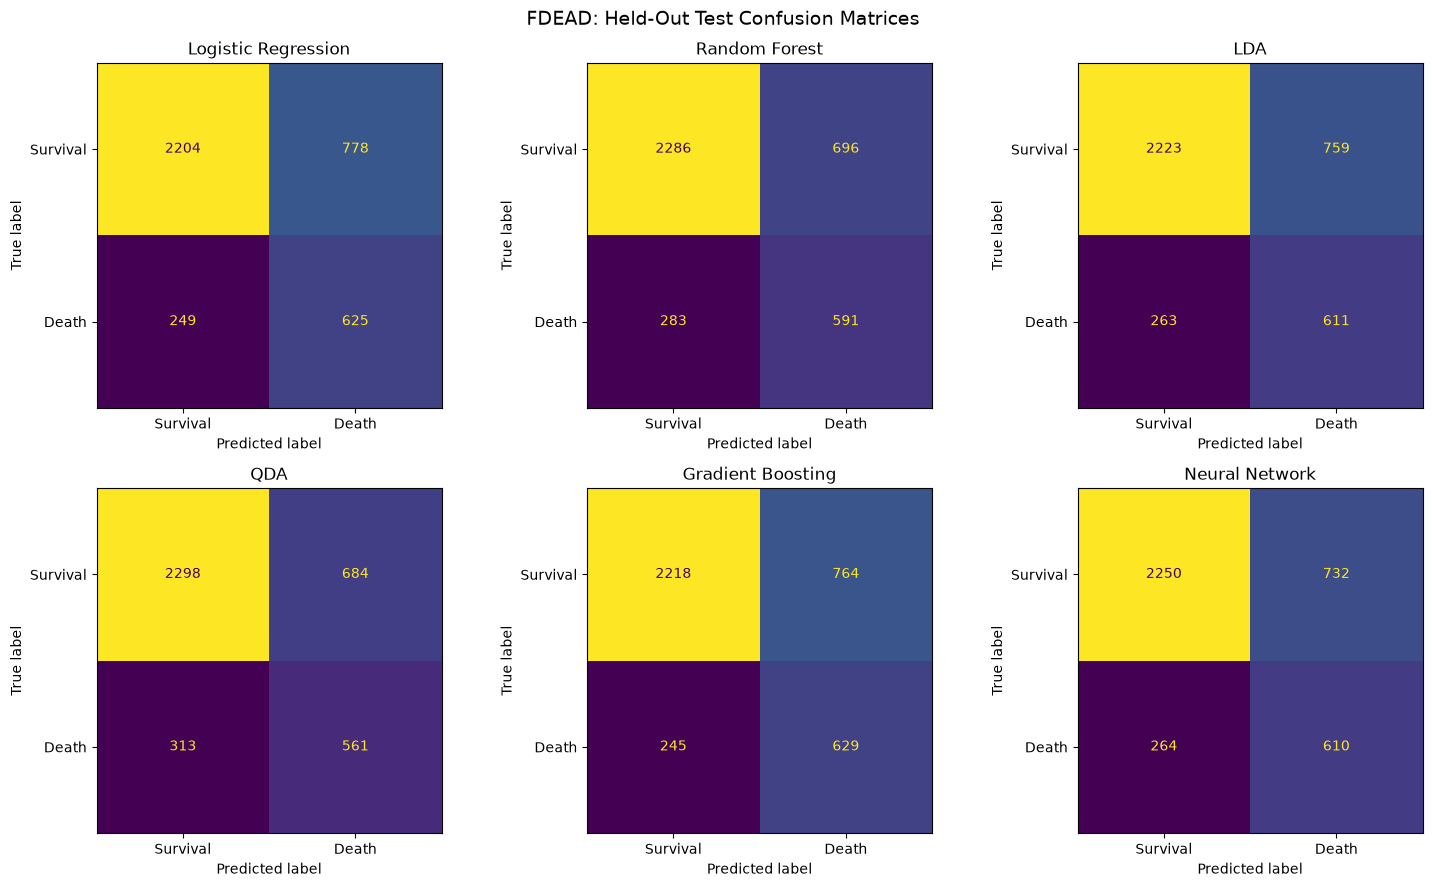

#### ROC Curves

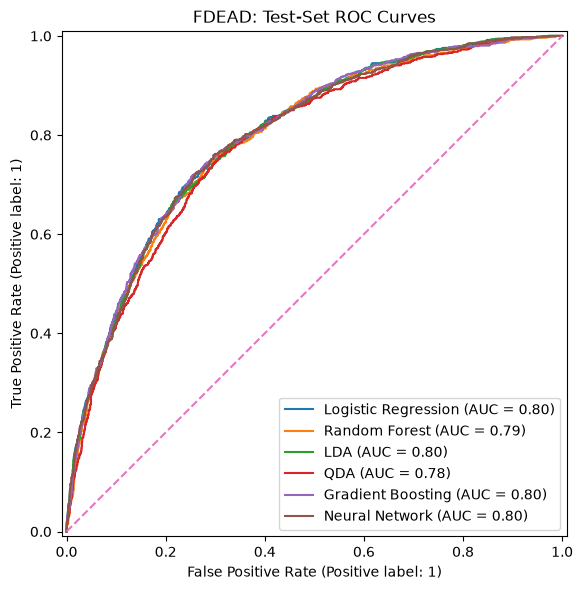

#### Calibration Analysis

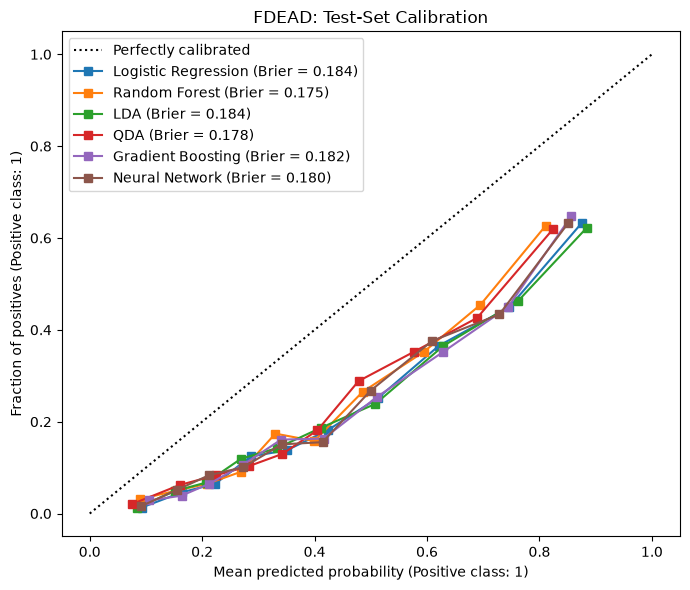

#### Predicted Probability Distributions

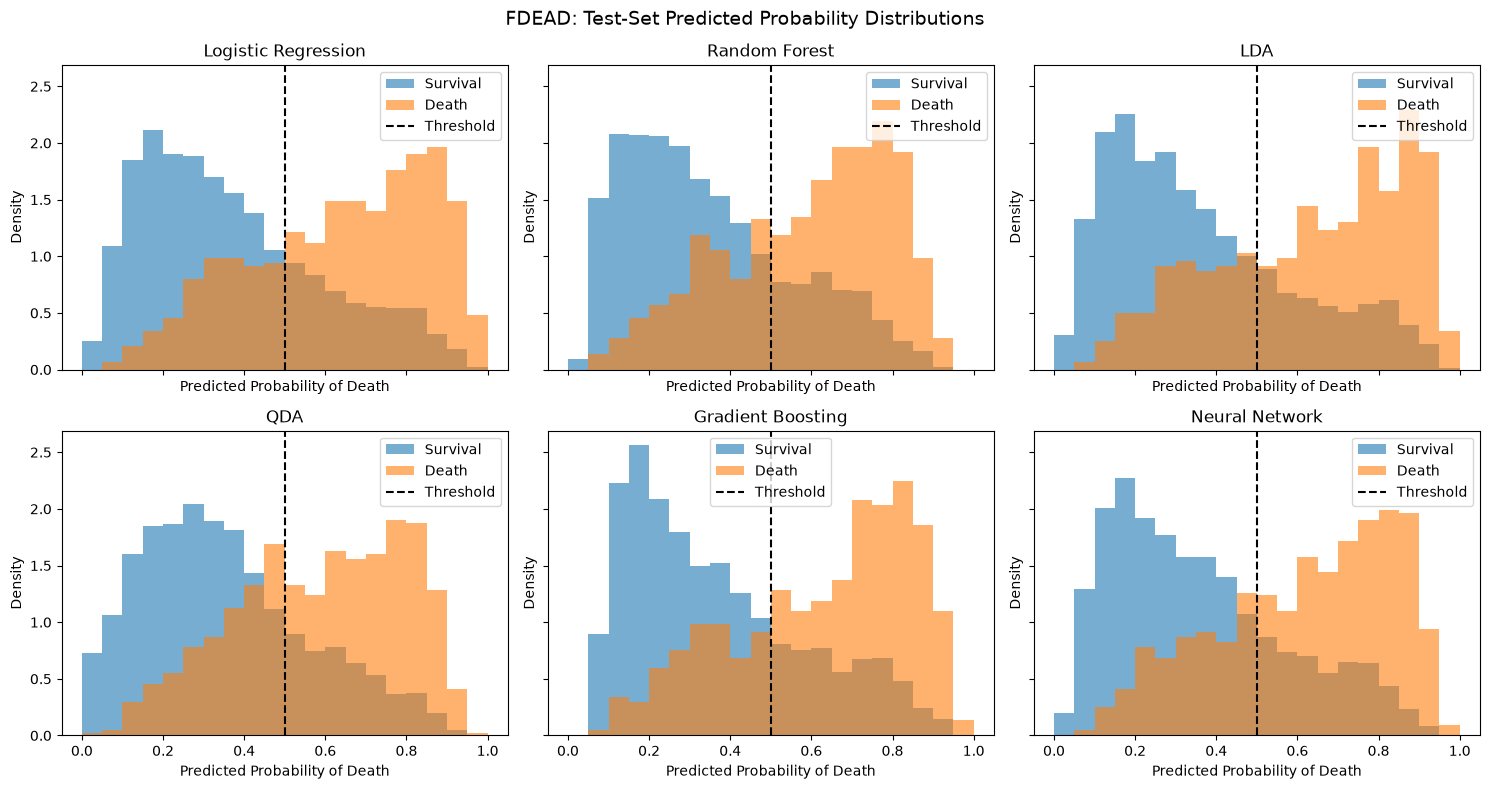

### Model Interpretation

#### Logistic Regression Coefficients and Odds Ratios

,feature,coefficient,odds_ratio,absolute_coefficient
0,cat__RCONSC_U,1.982578,7.261441,1.982578
1,cat__RCONSC_D,0.858226,2.358972,0.858226
2,cat__RDEF7_Y,0.686351,1.986453,0.686351
3,num__AGE,0.664321,1.943170,0.664321
4,cat__RDEF4_C,0.579109,1.784448,0.579109
5,cat__RDEF5_C,0.497451,1.644524,0.497451
6,cat__RATRIAL_Y,0.479684,1.615564,0.479684
7,cat__STYPE_POCS,-0.457784,0.632684,0.457784
8,cat__RDEF1_C,0.402266,1.495209,0.402266
9,cat__RHEP24_Missing,-0.393627,0.674605,0.393627


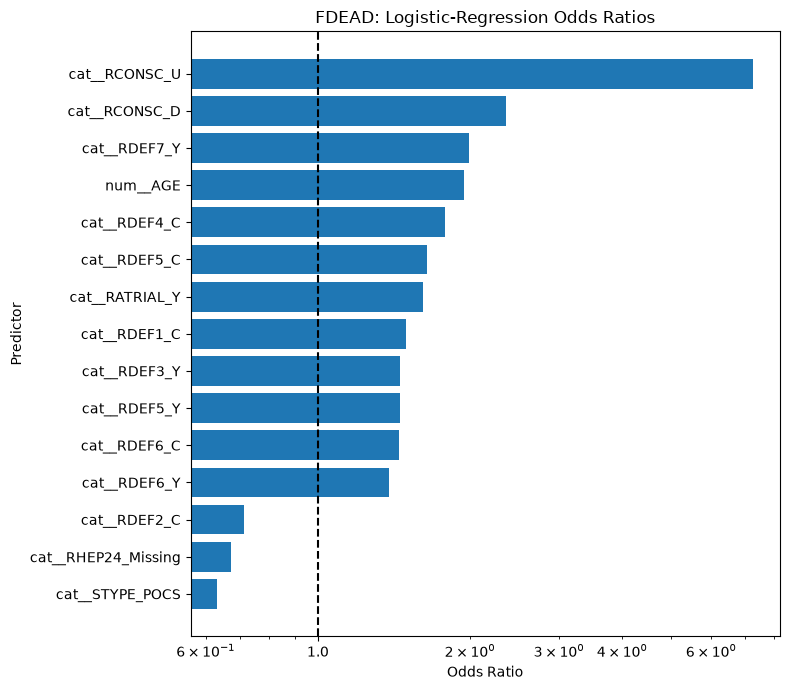

#### Gradient Boosting Permutation Importance

,feature,importance_mean,importance_std
0,AGE,0.063780,0.006832
1,RCONSC,0.036037,0.003991
2,RDEF5,0.011574,0.003012
3,STYPE,0.008875,0.002782
4,RDEF1,0.007669,0.002082
5,RDEF3,0.007165,0.002065
6,RCT,0.007106,0.001208
7,RSBP,0.006564,0.001913
8,RATRIAL,0.005928,0.003359
9,RDEF4,0.005414,0.002627


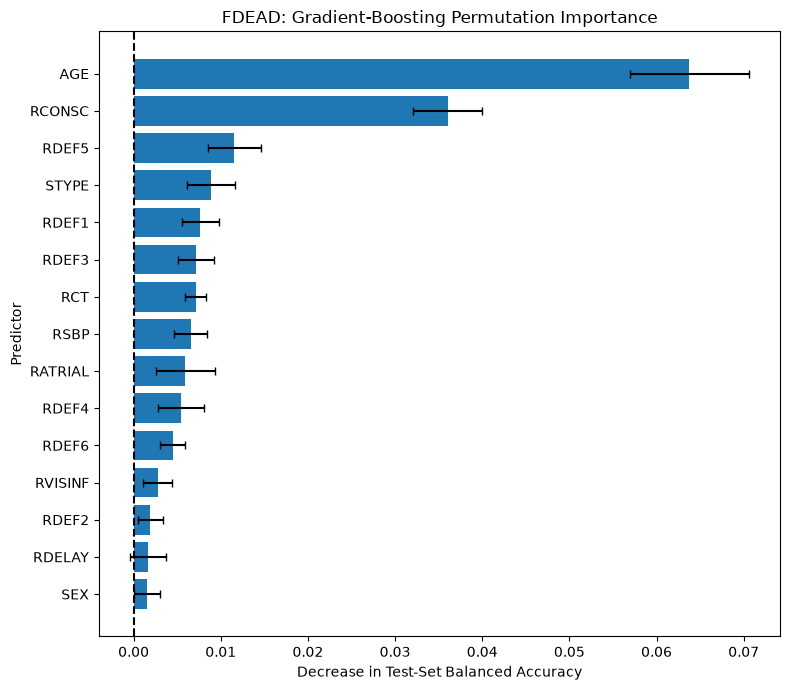

In [21]:
fdead_results = run_outcome_analysis(
    data=fdead_data,
    outcome="FDEAD",
    positive_label="Death",
    negative_label="Survival",
)


### FDEAD Interpretation

#### Cross-Validation Interpretation

The six model classes produced similar cross-validation results for six-month mortality. LDA achieved the highest mean balanced accuracy and was therefore selected under the prespecified primary criterion, while logistic regression and gradient boosting performed nearly as well. ROC-AUC values were also closely grouped, indicating that several models had comparable ability to rank patients by mortality risk. QDA produced slightly weaker balanced accuracy and discrimination than the other classifiers.

Logistic regression, LDA, and QDA showed very small training-to-validation gaps, indicating stable generalization across folds. Gradient boosting and the neural network showed modest gaps. Random forest exhibited substantially higher training performance than validation performance, providing the clearest evidence of overfitting. Overall, cross-validation favored LDA, but the small differences among the leading models do not indicate a decisive advantage.

#### Held-Out Test-Set Interpretation

Performance on the held-out mortality test set was consistent with the cross-validation results. Gradient boosting achieved the strongest balanced accuracy, ROC-AUC, recall, and F1 score, while random forest achieved the highest ordinary accuracy and precision. The cross-validation-selected LDA model remained competitive but did not lead the held-out comparison.

The change in model ordering between cross-validation and the held-out test set reflects the small performance differences among the leading algorithms and the sampling variability associated with a single test partition. The held-out results should therefore be interpreted as an evaluation of the models selected during development rather than as a basis for replacing the cross-validation-selected model.

#### Calibration Interpretation

All six mortality calibration curves fell primarily below the perfect-calibration line, indicating that the models generally overestimated the absolute probability of death. This pattern is consistent with fitting procedures that gave the smaller mortality class greater influence than its observed prevalence would otherwise provide.

Random forest achieved the lowest Brier score, followed by QDA and the neural network, although the differences were modest. The models demonstrated useful discrimination but did not produce reliable estimates of absolute mortality risk. Their predicted probabilities would require recalibration before being interpreted as individualized mortality probabilities.

#### Predicted-Probability Distribution Interpretation

For every model, patients who died generally received higher predicted mortality probabilities than patients who survived. The mortality distributions showed the clearest separation of the three outcomes, consistent with the comparatively strong ROC-AUC results. Nevertheless, considerable overlap remained, particularly around the classification threshold, so no model separated deaths from survivals perfectly.

The six classifiers produced broadly similar distribution patterns. Differences in the amount of probability mass on either side of the threshold explain their modest differences in precision, recall, and ordinary accuracy more than any major difference in overall discrimination.

#### Logistic-Regression Interpretation

The logistic-regression coefficients describe adjusted associations with the modeled odds of six-month death. Unconsciousness at presentation had the strongest positive association with mortality, while drowsy consciousness was also associated with higher predicted mortality. Greater age, the presence of RDEF7, atrial fibrillation, and several unassessable neurological findings were also associated with higher modeled odds of death.

Posterior-circulation stroke syndrome was associated with lower predicted mortality than the LACS reference category. For age, the odds ratio represents a one-standard-deviation increase; categorical odds ratios compare each displayed category with its prespecified reference category. These coefficients describe predictive associations within the fitted model and should not be interpreted as causal effects.

#### Gradient-Boosting Interpretation

Gradient-boosting permutation importance identified age as the strongest contributor to held-out mortality classification, followed by level of consciousness. Neurological deficits, stroke subtype, CT status, systolic blood pressure, and atrial fibrillation provided smaller additional contributions.

The dominance of age and consciousness indicates that general patient vulnerability and initial stroke severity supplied much of the model’s mortality signal. Permutation importance measures the reduction in performance after a predictor is disrupted; it does not indicate the direction of an association or establish causality.

## 5. Six-Month Dependency: FDENNIS

### Model Development

,observations,predictors
Training,11905,22
Held-out test,2977,22


,Training (%),Held-out test (%)
FDENNIS,,
Dependency,51.92,51.93
Independence,48.08,48.07


FDENNIS: tuning Logistic Regression
FDENNIS: tuning Random Forest
FDENNIS: tuning LDA
FDENNIS: tuning QDA
FDENNIS: tuning Gradient Boosting
FDENNIS: tuning Neural Network


### Cross-Validation Results

...

,train_balanced_accuracy,validation_balanced_accuracy,train_roc_auc,validation_roc_auc,balanced_accuracy_gap,roc_auc_gap
model,,,,,,
Logistic Regression,0.696,0.693,0.758,0.754,0.003,0.004
Random Forest,0.742,0.692,0.828,0.753,0.050,0.075
LDA,0.695,0.693,0.758,0.754,0.002,0.004
QDA,0.680,0.678,0.746,0.742,0.002,0.004
Gradient Boosting,0.699,0.693,0.767,0.755,0.006,0.012
Neural Network,0.705,0.691,0.770,0.753,0.014,0.017


### Held-Out Test Performance

,model,accuracy,balanced_accuracy,roc_auc,precision,recall,f1
0,Logistic Regression,0.681,0.682,0.747,0.707,0.658,0.682
1,Random Forest,0.690,0.690,0.747,0.714,0.671,0.692
2,LDA,0.684,0.685,0.746,0.713,0.655,0.683
3,QDA,0.670,0.674,0.737,0.730,0.580,0.646
4,Gradient Boosting,0.685,0.687,0.751,0.717,0.651,0.682
5,Neural Network,0.682,0.683,0.747,0.712,0.652,0.681


### Diagnostics

#### Confusion Matrices

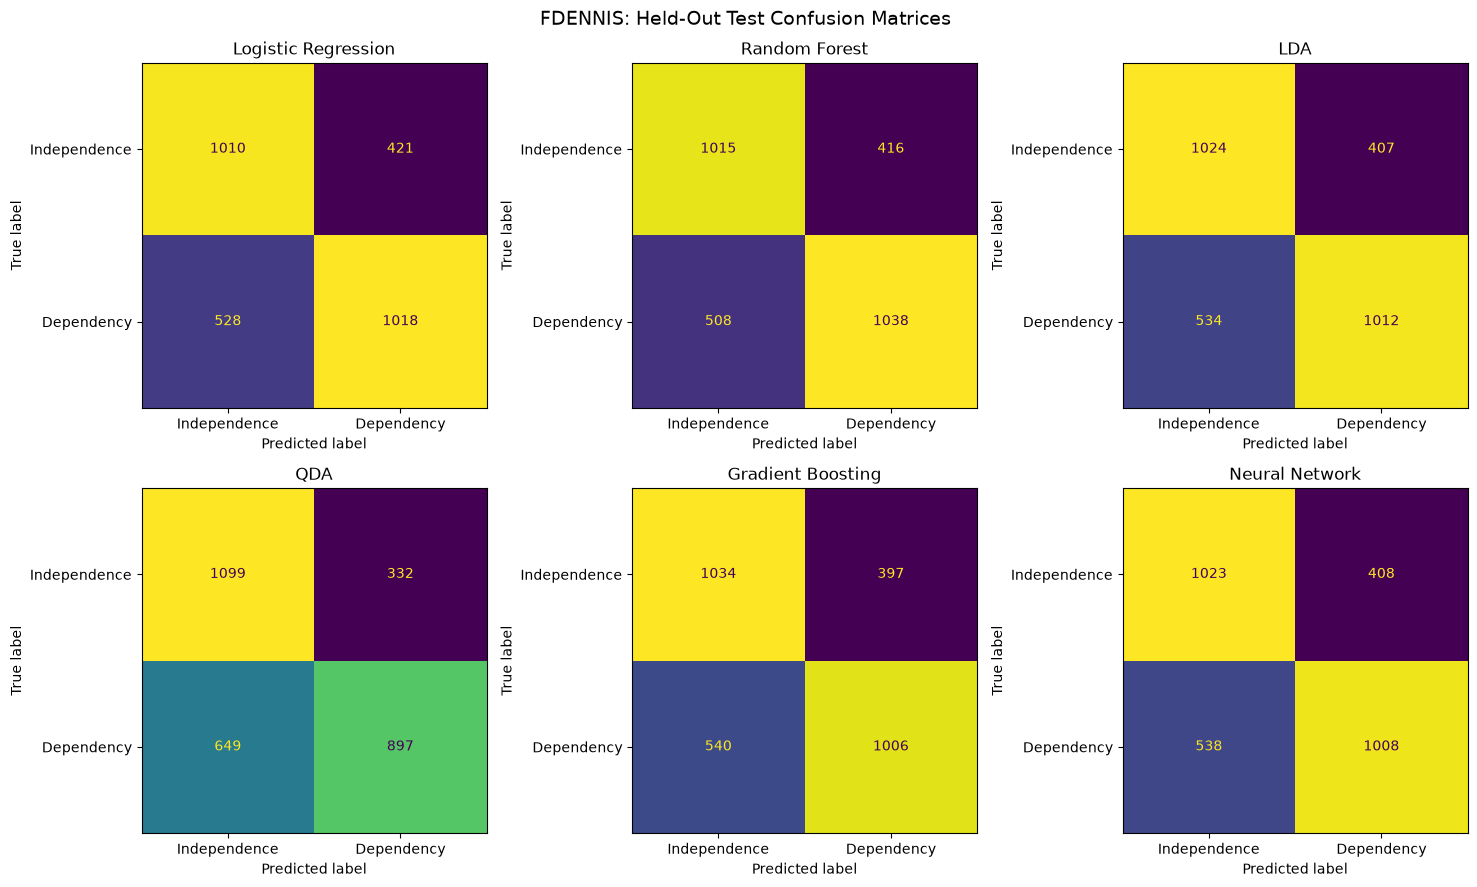

#### ROC Curves

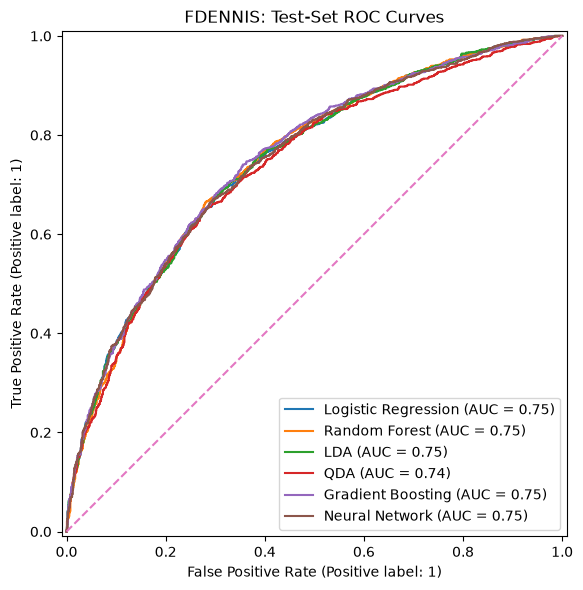

#### Calibration Analysis

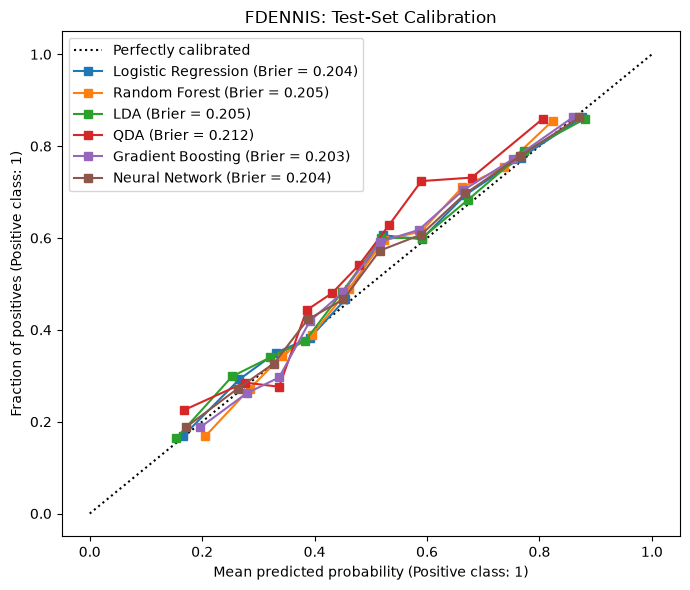

#### Predicted Probability Distributions

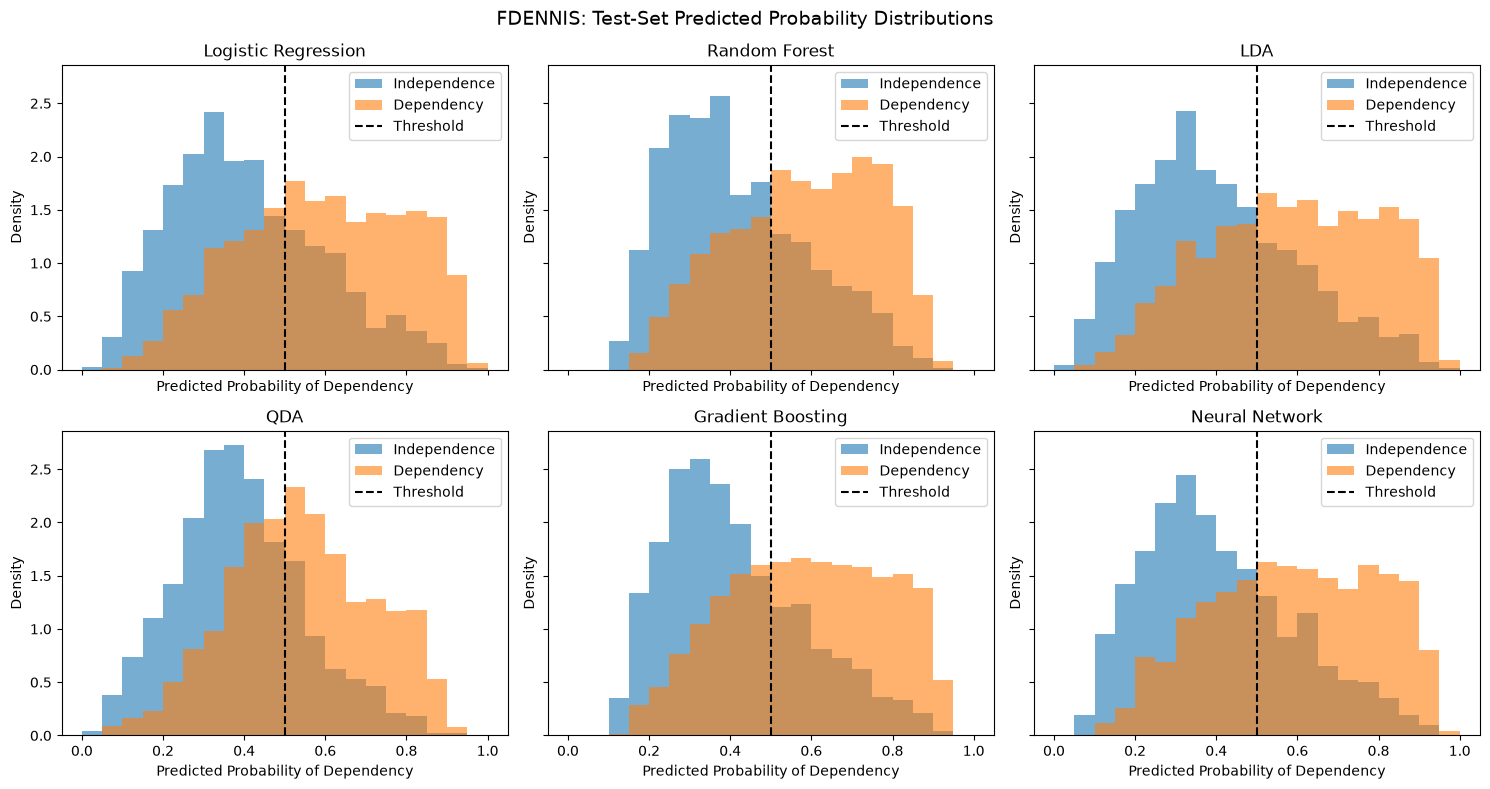

### Model Interpretation

#### Logistic Regression Coefficients and Odds Ratios

,feature,coefficient,odds_ratio,absolute_coefficient
0,cat__RCONSC_D,0.756480,2.130762,0.756480
1,cat__RDEF3_Y,0.685419,1.984603,0.685419
2,cat__RDEF6_Y,0.596384,1.815542,0.596384
3,cat__RCT_Y,-0.563531,0.569195,0.563531
4,cat__RCONSC_U,0.542579,1.720438,0.542579
5,cat__RDEF6_C,0.499009,1.647088,0.499009
6,num__AGE,0.447302,1.564087,0.447302
7,cat__RDEF5_Y,0.398172,1.489100,0.398172
8,cat__RDEF3_C,0.385190,1.469894,0.385190
9,cat__RDEF2_Y,0.356855,1.428829,0.356855


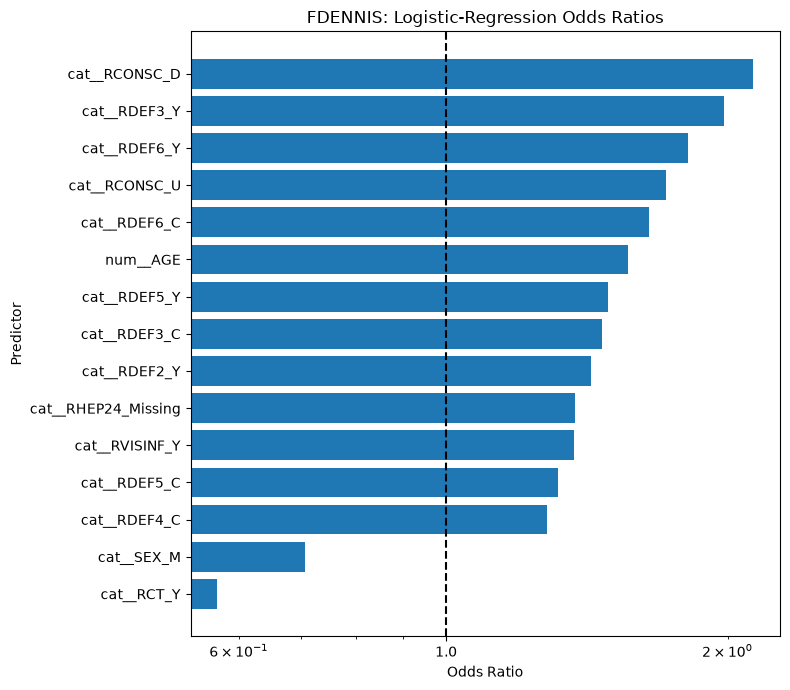

#### Gradient Boosting Permutation Importance

,feature,importance_mean,importance_std
0,AGE,0.055653,0.004645
1,RDEF3,0.022499,0.003739
2,RCT,0.016212,0.003291
3,RCONSC,0.014503,0.003563
4,STYPE,0.009924,0.005881
5,SEX,0.006809,0.003417
6,RDEF6,0.005858,0.004630
7,RDEF2,0.002386,0.001532
8,RDEF1,0.002247,0.001681
9,RVISINF,0.001948,0.001456


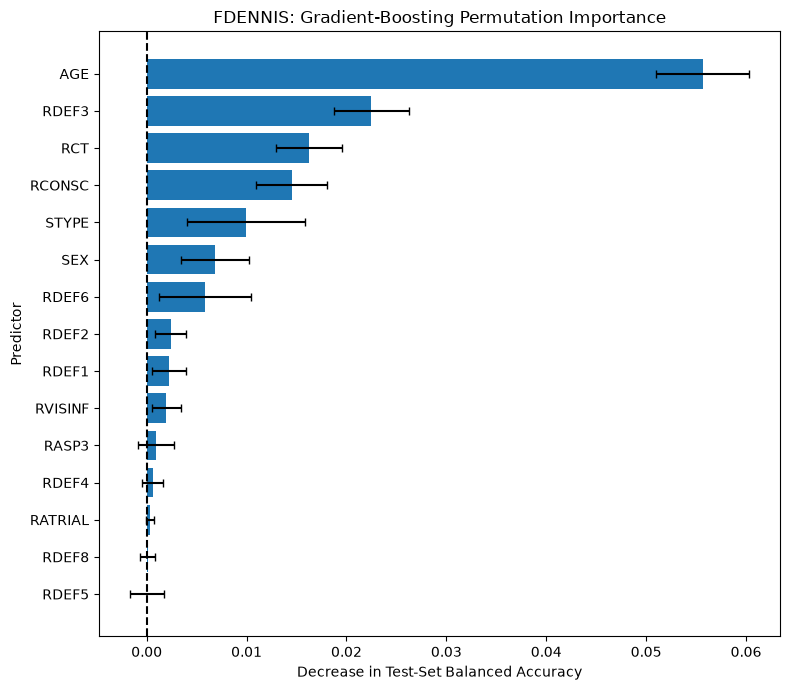

In [24]:
fdennis_results = run_outcome_analysis(
    data=fdennis_data,
    outcome="FDENNIS",
    positive_label="Dependency",
    negative_label="Independence",
)


### FDENNIS Interpretation

#### Cross-Validation Interpretation

Logistic regression, LDA, and gradient boosting produced nearly identical mean balanced accuracy for six-month dependency, while random forest and the neural network performed only slightly below them. Gradient boosting achieved the strongest ROC-AUC and was selected under the cross-validation ordering criteria. QDA produced lower balanced accuracy, ROC-AUC, recall, and F1 score, although it achieved comparatively high precision by making more conservative dependency classifications.

Logistic regression, LDA, QDA, and gradient boosting showed stable training-to-validation performance. The neural network demonstrated a small generalization gap, whereas random forest again showed the clearest evidence of overfitting. Overall, several models formed a closely matched leading group, with little evidence that greater algorithmic flexibility substantially improved prediction.

#### Held-Out Test-Set Interpretation

On the held-out dependency test set, random forest achieved the strongest ordinary accuracy, balanced accuracy, recall, and F1 score, while gradient boosting achieved the highest ROC-AUC. QDA again produced the highest precision but the lowest recall, reflecting a more conservative tendency to classify patients as dependent.

The cross-validation-selected gradient-boosting model remained competitive on every test metric, although random forest performed slightly better at the default classification threshold. As with mortality, the change in model ordering between cross-validation and the held-out test set is consistent with closely matched models evaluated on different samples and does not establish a decisively superior test-set algorithm.

#### Calibration Interpretation

The dependency calibration curves generally followed the perfect-calibration line more closely than the mortality and recovery curves. Gradient boosting achieved the lowest Brier score, with logistic regression, the neural network, random forest, and LDA producing very similar probability accuracy. QDA showed the largest local departures from the diagonal and the highest Brier score.

Although calibration varied across portions of the probability range, the dependency models produced reasonably consistent correspondence between predicted probabilities and observed dependency frequencies. These probabilities were more reliable than those produced for the two less balanced outcomes, although external calibration would still be required before clinical use.

#### Predicted-Probability Distribution Interpretation

Across all six classifiers, dependent patients generally received higher predicted dependency probabilities than independent patients. The distributions showed meaningful separation but also substantial overlap, consistent with moderate discrimination rather than highly accurate individual classification.

Random forest and gradient boosting produced favorable classification performance despite distributions similar to those of the linear models. QDA placed fewer dependent patients above the classification threshold, explaining its relatively high precision and lower recall. Overall, the models extracted similar dependency information but applied somewhat different classification boundaries.

#### Logistic-Regression Interpretation

The logistic-regression coefficients describe adjusted associations with the modeled odds of six-month dependency among patients with an observed dependency outcome. Drowsy consciousness had the strongest positive association with dependency. Leg or foot deficit, RDEF6 status, unconsciousness, greater age, hemianopia, and other neurological deficits were also associated with higher predicted dependency.

CT imaging before randomization was associated with lower modeled dependency odds relative to its reference category. Because these coefficients come from a multivariable predictive model, they represent conditional predictive associations and should not be interpreted as isolated causal effects.

#### Gradient-Boosting Interpretation

Age was the most important predictor of held-out dependency classification in the gradient-boosting model. Leg or foot deficit was the next most influential predictor, followed by CT status, level of consciousness, and stroke subtype. Sex and several additional neurological variables contributed smaller amounts of predictive information.

These results suggest that dependency prediction relied primarily on age and baseline neurological severity, with imaging and stroke classification providing additional information. The importance values measure the model’s dependence on each original predictor and do not show whether that predictor increased or decreased dependency probability.



## 6. Six-Month Recovery: FRECOVER

### Model Development

,observations,predictors
Training,11844,22
Held-out test,2961,22


,Training (%),Held-out test (%)
FRECOVER,,
No recovery,74.89,74.91
Recovery,25.11,25.09


FRECOVER: tuning Logistic Regression
FRECOVER: tuning Random Forest
FRECOVER: tuning LDA
FRECOVER: tuning QDA
FRECOVER: tuning Gradient Boosting
FRECOVER: tuning Neural Network


### Cross-Validation Results

...

,train_balanced_accuracy,validation_balanced_accuracy,train_roc_auc,validation_roc_auc,balanced_accuracy_gap,roc_auc_gap
model,,,,,,
Logistic Regression,0.639,0.635,0.689,0.682,0.003,0.007
Random Forest,0.681,0.634,0.754,0.679,0.047,0.075
LDA,0.640,0.636,0.689,0.682,0.004,0.006
QDA,0.632,0.626,0.682,0.674,0.006,0.008
Gradient Boosting,0.648,0.634,0.703,0.682,0.014,0.020
Neural Network,0.655,0.636,0.710,0.680,0.019,0.031


### Held-Out Test Performance

,model,accuracy,balanced_accuracy,roc_auc,precision,recall,f1
0,Logistic Regression,0.600,0.607,0.660,0.338,0.622,0.438
1,Random Forest,0.605,0.619,0.662,0.346,0.649,0.452
2,LDA,0.623,0.613,0.660,0.351,0.592,0.441
3,QDA,0.541,0.606,0.654,0.320,0.736,0.446
4,Gradient Boosting,0.610,0.621,0.666,0.349,0.643,0.453
5,Neural Network,0.638,0.617,0.657,0.361,0.576,0.444


### Diagnostics

#### Confusion Matrices

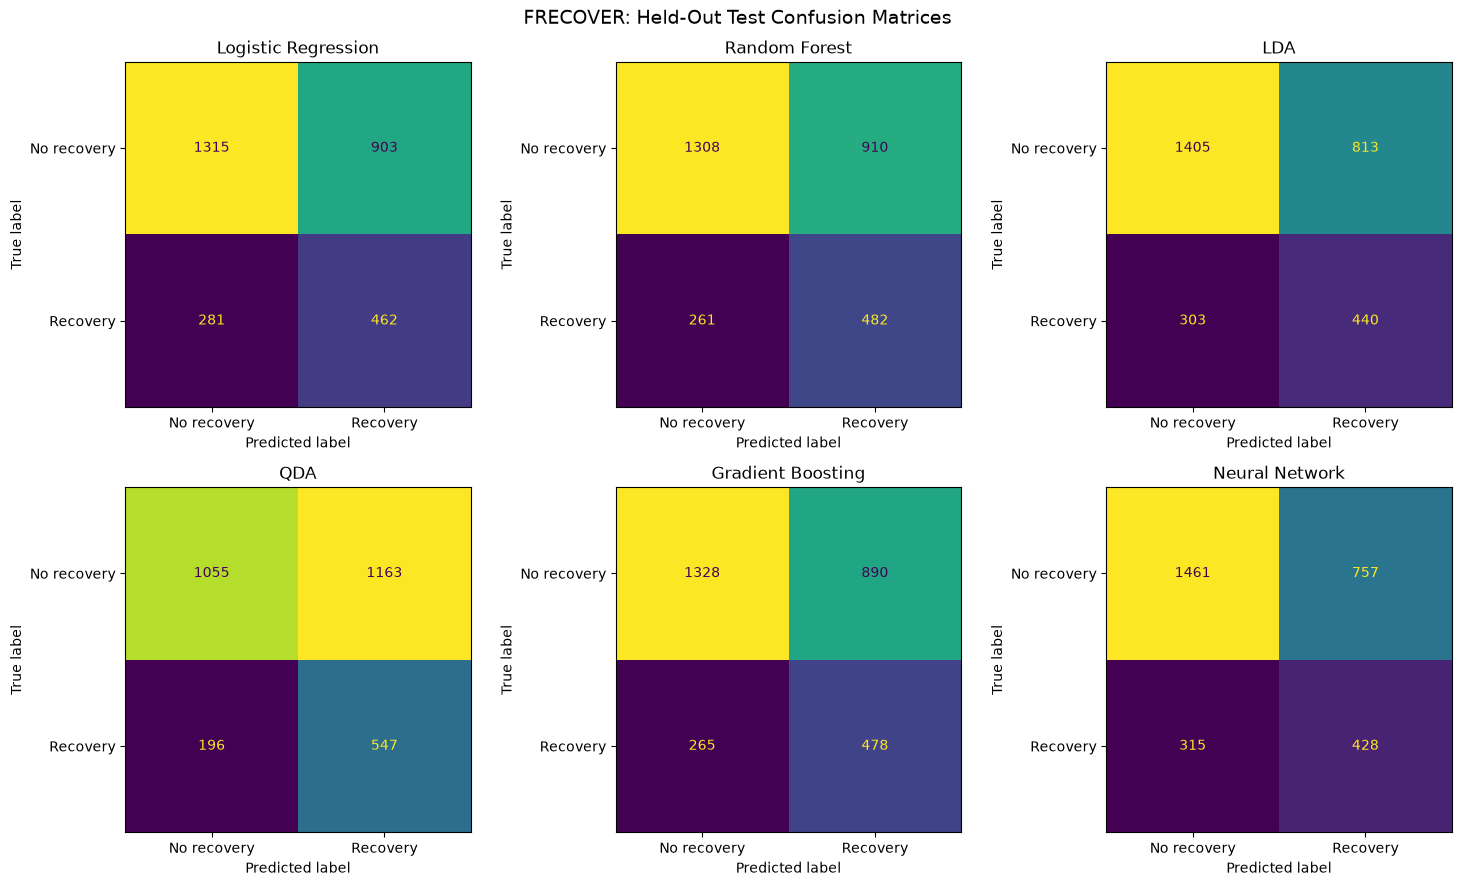

#### ROC Curves

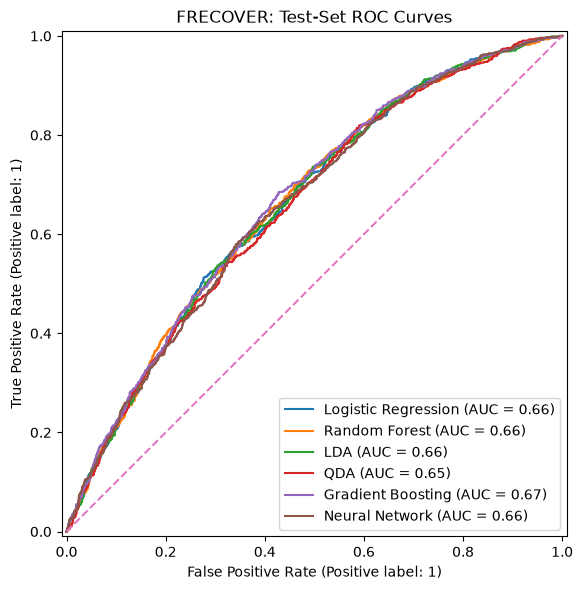

#### Calibration Analysis

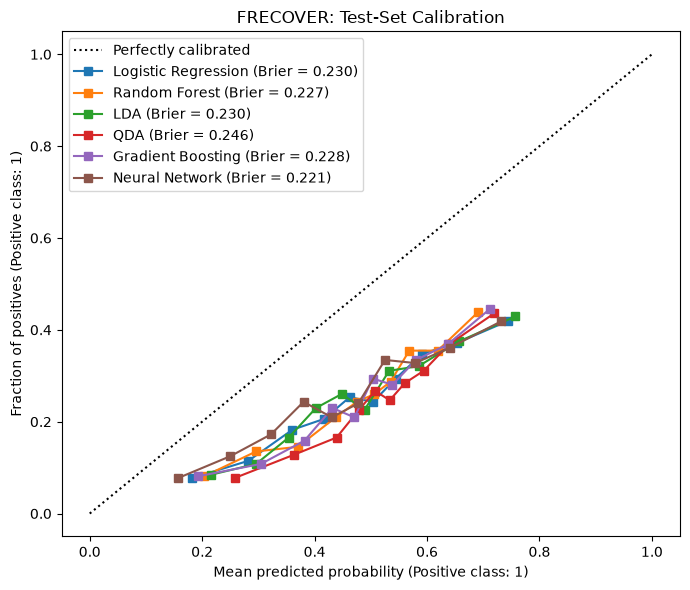

#### Predicted Probability Distributions

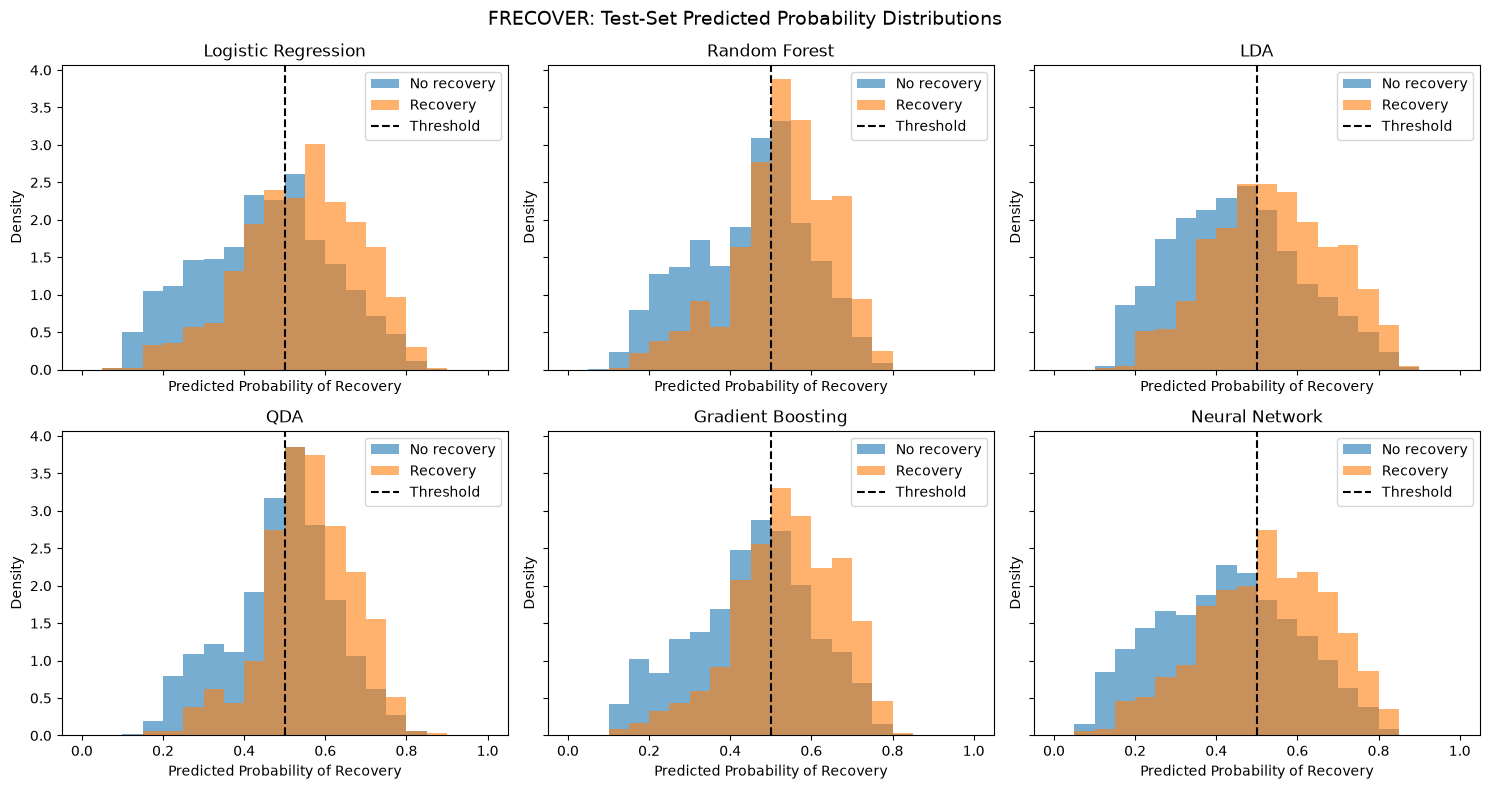

### Model Interpretation

#### Logistic Regression Coefficients and Odds Ratios

,feature,coefficient,odds_ratio,absolute_coefficient
0,cat__RDEF3_C,-0.828143,0.436860,0.828143
1,cat__RDEF3_Y,-0.646055,0.524109,0.646055
2,cat__RDEF1_C,-0.596490,0.550741,0.596490
3,cat__RCONSC_D,-0.572303,0.564225,0.572303
4,cat__RDEF2_C,0.505743,1.658216,0.505743
5,cat__RDEF5_Y,-0.446063,0.640143,0.446063
6,cat__RDEF6_C,-0.384577,0.680739,0.384577
7,cat__RDEF2_Y,-0.364193,0.694757,0.364193
8,cat__RCT_Y,0.345816,1.413143,0.345816
9,cat__RVISINF_Y,-0.334170,0.715932,0.334170


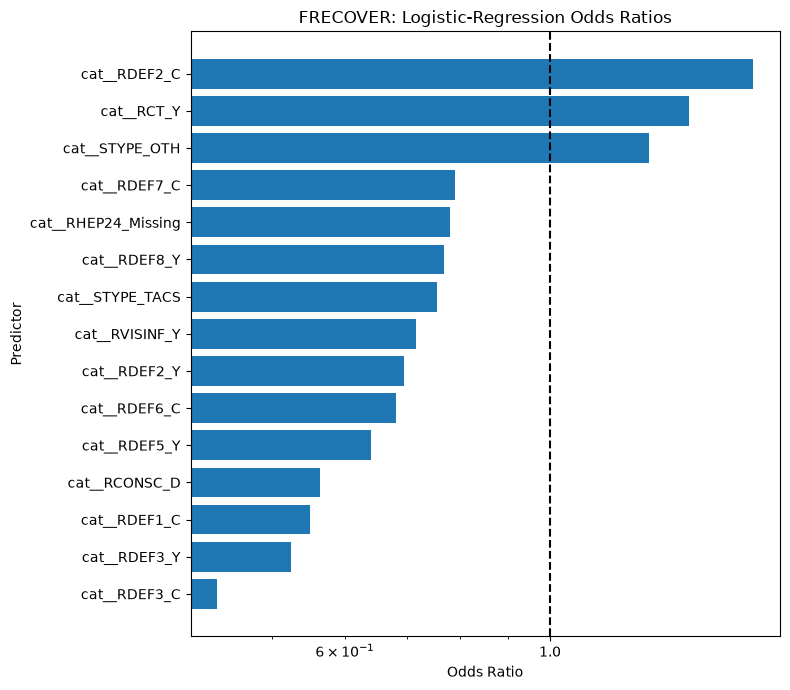

#### Gradient Boosting Permutation Importance

,feature,importance_mean,importance_std
0,RDEF3,0.023396,0.005266
1,STYPE,0.014687,0.004039
2,AGE,0.011418,0.005901
3,RDEF5,0.008770,0.003911
4,RCONSC,0.008001,0.003113
5,RDEF6,0.006337,0.003842
6,RVISINF,0.005017,0.003092
7,RDEF2,0.005014,0.003333
8,RDELAY,0.004249,0.003537
9,RCT,0.003529,0.002593


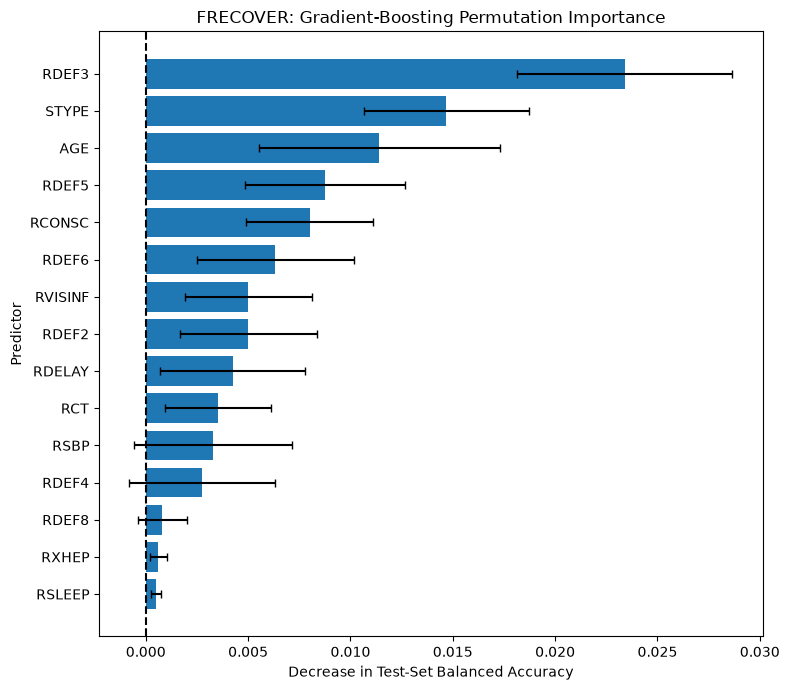

In [27]:
frecover_results = run_outcome_analysis(
    data=frecover_data,
    outcome="FRECOVER",
    positive_label="Recovery",
    negative_label="No recovery",
)


### FRECOVER Interpretation

#### Cross-Validation Interpretation

All six model classes produced similar cross-validation performance for six-month recovery. LDA and the neural network achieved the highest mean balanced accuracy, and LDA was selected after considering ROC-AUC as the secondary ordering metric. Logistic regression, random forest, and gradient boosting performed nearly as well. QDA produced slightly lower balanced accuracy but substantially higher recall, reflecting a greater tendency to predict recovery.

Logistic regression and LDA demonstrated the most stable training-to-validation performance. QDA was also stable, whereas gradient boosting and the neural network showed modest generalization gaps. Random forest exhibited the clearest evidence of overfitting. Overall, cross-validation did not identify a decisively superior recovery model.

#### Held-Out Test-Set Interpretation

Gradient boosting achieved the strongest held-out balanced accuracy, ROC-AUC, and F1 score for recovery, although its advantage over random forest, the neural network, and LDA was modest. The neural network achieved the highest ordinary accuracy and precision but lower recall, reflecting more conservative recovery classifications. QDA achieved the highest recall but the lowest precision and ordinary accuracy, indicating that it detected more recovered patients at the cost of more false-positive recovery predictions.

The cross-validation-selected LDA model remained competitive but did not lead the held-out comparison. This rank reversal, together with the small absolute differences among models, indicates that the leading algorithms were closely matched and that their ordering was sensitive to the particular data partition.

#### Calibration Interpretation

All six recovery calibration curves fell primarily below the perfect-calibration line, indicating that the models generally overestimated the absolute probability of recovery. The neural network achieved the lowest Brier score, followed by random forest and gradient boosting, while QDA demonstrated the weakest probability accuracy.

The models produced useful classifications but less reliable absolute probability estimates. Because the modeling procedures increased the influence of the smaller recovery class, raw predicted probabilities should not be interpreted as calibrated estimates of a patient’s recovery likelihood without an additional calibration procedure.

#### Predicted-Probability Distribution Interpretation

Across all six models, recovered patients generally received higher predicted recovery probabilities than patients who did not recover, indicating that every model captured meaningful prognostic information. However, the distributions overlapped substantially for every classifier, consistent with the comparatively modest recovery ROC-AUC values and the difficulty of distinguishing the two outcome groups.

QDA assigned a larger proportion of patients probabilities above the classification threshold, explaining its high recall and lower precision. The neural network made more conservative recovery classifications and therefore achieved higher precision but lower recall. No model achieved strong separation between recovered and non-recovered patients.

#### Logistic-Regression Interpretation

The strongest negative associations with six-month recovery involved leg or foot function that could not be assessed, a documented leg or foot deficit, an unassessable facial deficit, and drowsy consciousness. Hemianopia, RDEF6 status, a documented arm or hand deficit, and visible infarction were also associated with lower modeled recovery odds.

Arm or hand function that could not be assessed and CT imaging before randomization were associated with higher predicted recovery odds. The positive association for an unassessable deficit should be interpreted cautiously because this category may reflect complex clinical or recording patterns rather than a direct beneficial relationship. These coefficients represent adjusted predictive associations, not causal effects.

#### Gradient-Boosting Interpretation

Leg or foot deficit was the most important predictor of held-out recovery classification in the gradient-boosting model. Stroke subtype and age were the next most influential predictors, followed by hemianopia and level of consciousness. Several additional neurological, imaging, and timing variables provided smaller contributions.

The results indicate that baseline neurological impairment, stroke severity, and age were the principal sources of recovery information used by the model. Permutation importance measures dependence of predictive performance on a predictor but does not show the direction of its relationship with recovery.



## 7. Cross-Outcome Model Comparison

In [36]:
all_results = {
    "FDEAD": fdead_results,
    "FDENNIS": fdennis_results,
    "FRECOVER": frecover_results,
}


### 7.1 Cross-Validation Comparison

In [38]:
cross_outcome_cv = pd.concat(
    [
        (
            results["cv_performance_summary"]
            .reset_index()
            .assign(outcome=outcome)
        )
        for outcome, results in all_results.items()
    ],
    ignore_index=True,
)

cross_outcome_cv = cross_outcome_cv[
    [
        "outcome",
        "model",
        "accuracy",
        "balanced_accuracy",
        "roc_auc",
        "precision",
        "recall",
        "f1",
    ]
]

display(cross_outcome_cv)


,outcome,model,accuracy,balanced_accuracy,roc_auc,precision,recall,f1
0,FDEAD,Logistic Regression,0.737,0.727,0.798,0.449,0.709,0.550
1,FDEAD,Random Forest,0.750,0.725,0.794,0.464,0.680,0.552
2,FDEAD,LDA,0.740,0.728,0.797,0.453,0.706,0.552
3,FDEAD,QDA,0.755,0.719,0.787,0.471,0.653,0.547
4,FDEAD,Gradient Boosting,0.734,0.727,0.797,0.446,0.713,0.549
5,FDEAD,Neural Network,0.731,0.726,0.795,0.442,0.718,0.547
6,FDENNIS,Logistic Regression,0.692,0.693,0.754,0.718,0.669,0.693
7,FDENNIS,Random Forest,0.691,0.692,0.753,0.715,0.674,0.694
8,FDENNIS,LDA,0.692,0.693,0.754,0.721,0.664,0.691
9,FDENNIS,QDA,0.674,0.678,0.742,0.735,0.584,0.650


### 7.2 Held-Out Test Comparison

In [40]:
cross_outcome_test = pd.concat(
    [
        (
            results["test_results"]
            .assign(outcome=outcome)
        )
        for outcome, results in all_results.items()
    ],
    ignore_index=True,
)

cross_outcome_test = cross_outcome_test[
    [
        "outcome",
        "model",
        "accuracy",
        "balanced_accuracy",
        "roc_auc",
        "precision",
        "recall",
        "f1",
    ]
]

display(cross_outcome_test)


,outcome,model,accuracy,balanced_accuracy,roc_auc,precision,recall,f1
0,FDEAD,Logistic Regression,0.734,0.727,0.797,0.445,0.715,0.549
1,FDEAD,Random Forest,0.746,0.721,0.791,0.459,0.676,0.547
2,FDEAD,LDA,0.735,0.722,0.795,0.446,0.699,0.545
3,FDEAD,QDA,0.741,0.706,0.785,0.451,0.642,0.529
4,FDEAD,Gradient Boosting,0.738,0.732,0.798,0.452,0.720,0.555
5,FDEAD,Neural Network,0.742,0.726,0.795,0.455,0.698,0.551
6,FDENNIS,Logistic Regression,0.681,0.682,0.747,0.707,0.658,0.682
7,FDENNIS,Random Forest,0.690,0.690,0.747,0.714,0.671,0.692
8,FDENNIS,LDA,0.684,0.685,0.746,0.713,0.655,0.683
9,FDENNIS,QDA,0.670,0.674,0.737,0.730,0.580,0.646


### 7.3 Cross-Validated Model Selection by Outcome

In [42]:
# Select the leading algorithm for each outcome using cross-validation rather
# than the held-out test set. Balanced accuracy is primary and ROC-AUC is the
# secondary ordering metric.

best_cv_models = (
    cross_outcome_cv
    .sort_values(
        [
            "outcome",
            "balanced_accuracy",
            "roc_auc",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
    .groupby(
        "outcome",
        as_index=False,
    )
    .first()
)

display(best_cv_models)


,outcome,model,accuracy,balanced_accuracy,roc_auc,precision,recall,f1
0,FDEAD,LDA,0.740,0.728,0.797,0.453,0.706,0.552
1,FDENNIS,Gradient Boosting,0.692,0.693,0.755,0.722,0.661,0.690
2,FRECOVER,LDA,0.639,0.636,0.682,0.371,0.629,0.467


### 7.4 Cross-Outcome Interpretation

Predictive performance differed more across outcomes than across model classes. Six-month mortality produced the strongest discrimination, dependency produced intermediate performance, and recovery was the most difficult outcome to predict. Within each outcome, the six classifiers generally produced closely grouped balanced accuracy and ROC-AUC values.

Cross-validation selected LDA for mortality and recovery and gradient boosting for dependency. The leading held-out models differed: gradient boosting produced the strongest threshold-based balance for mortality and recovery, while random forest performed best for dependency at the default threshold. These rank changes do not invalidate the cross-validation selections. Instead, they demonstrate that the leading algorithms were sufficiently close for their ordering to vary across samples.

Logistic regression and LDA consistently showed stable training-to-validation performance. Random forest showed the greatest overfitting for all three outcomes, especially mortality, without a consistent improvement in validation discrimination. Gradient boosting generally provided a more favorable balance between flexibility and generalization. Overall, no model class dominated across every outcome, metric, and data partition.

## 8. Summary and Limitations

### Summary

A common leakage-resistant modeling framework was used to compare six classification algorithms for six-month mortality, dependency, and recovery after acute ischemic stroke. Hyperparameters were selected using stratified cross-validation with balanced accuracy as the primary criterion, and the resulting pipelines were evaluated on outcome-specific held-out test sets.

Mortality was the most predictable outcome, followed by dependency, while recovery showed the weakest separation between outcome groups. Differences among model classes were generally modest within each outcome. Cross-validation selected LDA for mortality and recovery and gradient boosting for dependency, although the identity of the leading model sometimes changed on the held-out test sets. An informal split-sensitivity check by using differing random seeds also produced small changes in model ordering. Together, these findings indicate that several algorithms achieved effectively similar predictive performance and that minor ranking differences should not be overinterpreted.

The simpler linear and discriminant models remained competitive with random forest, gradient boosting, and the neural network. Logistic regression and LDA demonstrated particularly stable generalization, while random forest consistently showed the largest training-to-validation gaps. Gradient boosting produced strong held-out performance without the same degree of overfitting and provided useful original-predictor permutation importance.

Across outcomes, age, level of consciousness, baseline neurological deficits, and stroke subtype were recurring sources of predictive information. Calibration was most favorable for dependency, whereas mortality and recovery probabilities were generally overestimated and would require recalibration before being interpreted as absolute clinical risks. Overall, the analysis supports a group of competitive prognostic models rather than a single universally superior algorithm, with final model choice depending on the outcome, desired classification tradeoff, interpretability, and probability-calibration requirements.

### Limitations

The three outcome analyses were based on different subsets of the original cohort because observations were removed only when the selected outcome was missing. Mortality status was available for nearly the complete cohort, whereas dependency and recovery outcomes were missing for a larger proportion of participants. If functional outcomes were not assessed for patients who died, the FDENNIS and FRECOVER models should be interpreted as predicting outcomes among patients with an observed functional assessment rather than among the complete randomized cohort. Systematic differences between included and excluded participants could introduce selection bias and limit generalizability.

Class imbalance was addressed using the mechanism available for each classifier. Logistic regression and random forest used balanced class weights, gradient boosting and the neural network used observation weights, and LDA and QDA used equal class priors. These approaches all reduced the influence of the observed class prevalence on classification, but they are not mathematically equivalent. Class and observation weights modify the contribution of observations during fitting, whereas equal priors modify the discriminant models’ posterior probabilities and classification rules. These adjustments may also affect probability calibration, particularly for outcomes whose observed prevalence differs substantially from the equal weighting imposed during modeling. Raw predicted probabilities should therefore be interpreted cautiously unless the models are recalibrated using separate data.

The predictor set included CT findings and randomized treatment assignments. Because these variables may not have been available at initial presentation, the models represent prediction after this information became available rather than prediction based exclusively on pretreatment baseline characteristics. Their intended prediction time should be clearly defined before clinical application.

Model development and evaluation were conducted within a historical clinical-trial dataset. Changes in stroke diagnosis, treatment, supportive care, and patient populations may limit applicability to contemporary practice. The held-out test sets provide internal validation but do not establish performance in different clinical settings, populations, or time periods. External validation in independent and more contemporary cohorts would be required before clinical use.

The hyperparameter searches examined relatively small prespecified grids. The selected configurations were the best among the values considered but may not represent the optimal configuration for each model class. The held-out test sets were also used to compare models and generate diagnostic and interpretation results. They should not be used for additional tuning, threshold selection, or model revision if their performance estimates are to remain unbiased.

Finally, the reported coefficients and permutation importances describe predictive relationships rather than causal effects. Logistic-regression odds ratios should not be interpreted as estimates of treatment effects or independent causal associations. Permutation importance indicates how strongly model performance depends on a predictor but does not establish the direction of its relationship with an outcome. Correlated predictors may also divide or obscure their apparent importance. These models should therefore be viewed as exploratory prognostic tools rather than systems for determining treatment eligibility or treatment benefit.
